In [2]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [6]:
browsers = ['brave', 'safari', 'tor', 'chrome', 'firefox']
conditions = ['easy', 'medium', 'hard', 'throttled']

# Load all metrics.csv files
metrics_dfs = []
for browser in browsers:
    for condition in conditions:
        path = f"metrics/{browser}/{condition}.csv"
        if os.path.exists(path):
            df = pd.read_csv(path)
            df['browser'] = browser
            df['condition'] = condition
            metrics_dfs.append(df)
metrics_df = pd.concat(metrics_dfs, ignore_index=True)

# Load all summary.csv files
summary_dfs = []
for browser in browsers:
    for condition in conditions:
        path = f"metrics/{browser}/{condition}_summary.csv"
        if os.path.exists(path):
            df = pd.read_csv(path)
            df['browser'] = browser
            df['condition'] = condition
            summary_dfs.append(df)
summary_df = pd.concat(summary_dfs, ignore_index=True)

# Load all mime.csv files
mime_dfs = []
for browser in browsers:
    for condition in conditions:
        path = f"metrics/{browser}/{condition}_mime.csv"
        if os.path.exists(path):
            df = pd.read_csv(path)
            df['browser'] = browser
            df['condition'] = condition
            mime_dfs.append(df)
mime_df = pd.concat(mime_dfs, ignore_index=True)

print(metrics_df.shape)
print(summary_df.shape)
print(mime_df.shape)



(285, 14)
(123, 25)
(959, 6)


/var/folders/3l/4gmrfkz56d3bfw4n04k4myj00000gn/T/ipykernel_67509/2490987159.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat(metrics_dfs, ignore_index=True)
/var/folders/3l/4gmrfkz56d3bfw4n04k4myj00000gn/T/ipykernel_67509/2490987159.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary_df = pd.concat(summary_dfs, ignore_index=True)


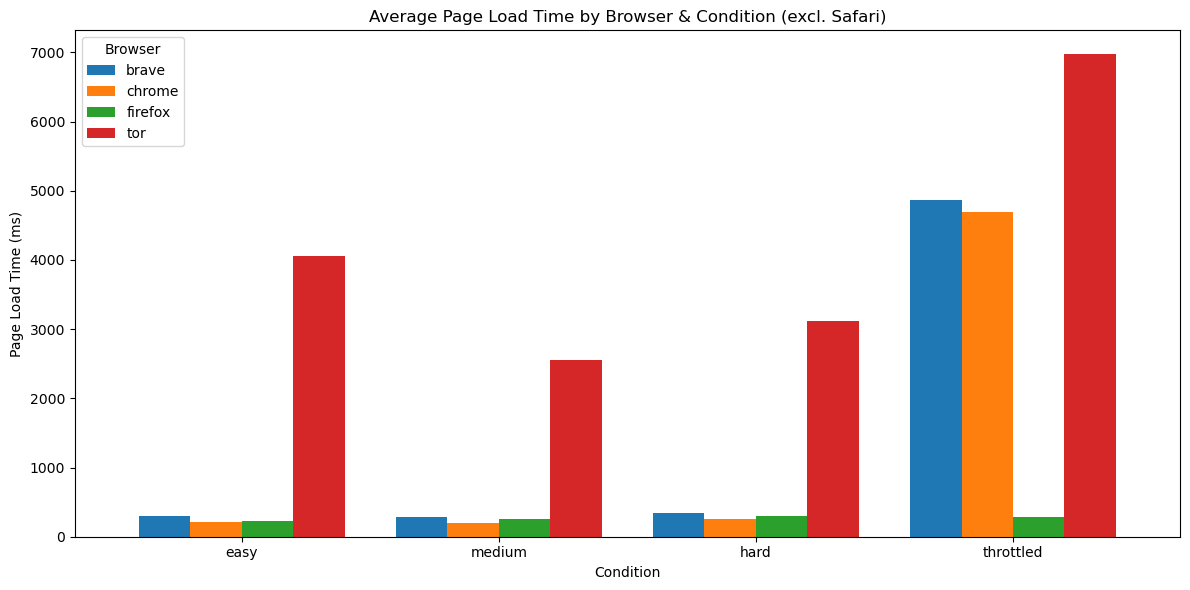

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

# Exclude Safari
filtered_df = metrics_df[metrics_df['browser'] != 'safari']

plt_data = filtered_df.groupby(['browser', 'condition'])['plt_ms'].mean().reset_index()
pivot = plt_data.pivot(index='condition', columns='browser', values='plt_ms')
pivot = pivot.reindex(['easy', 'medium', 'hard', 'throttled'])

pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Average Page Load Time by Browser & Condition (excl. Safari)')
ax.set_xlabel('Condition')
ax.set_ylabel('Page Load Time (ms)')
ax.legend(title='Browser')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

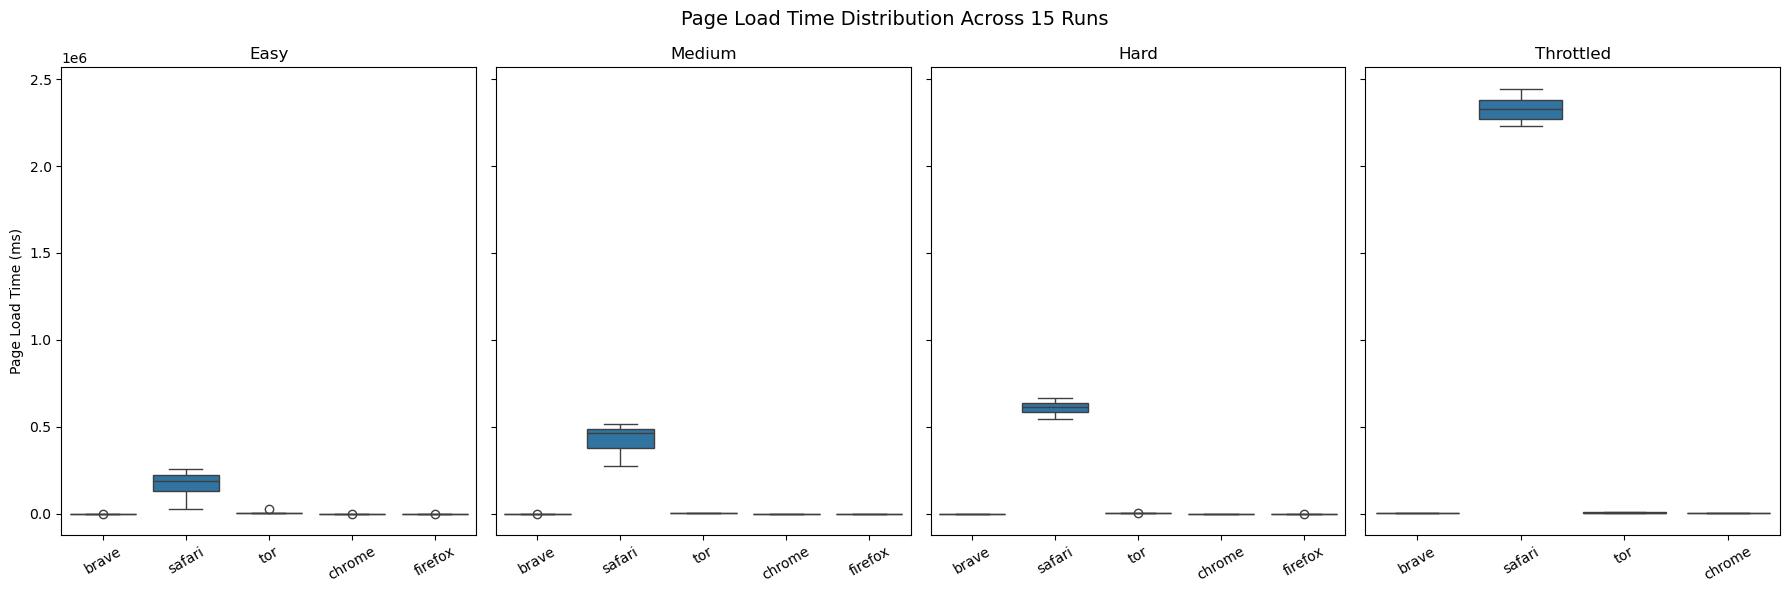

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)

for i, condition in enumerate(conditions):
    data = metrics_df[metrics_df['condition'] == condition]
    sns.boxplot(data=data, x='browser', y='plt_ms', ax=axes[i])
    axes[i].set_title(f'{condition.capitalize()}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    if i == 0:
        axes[i].set_ylabel('Page Load Time (ms)')
    else:
        axes[i].set_ylabel('')

fig.suptitle('Page Load Time Distribution Across 15 Runs', fontsize=14)
plt.tight_layout()
plt.show()

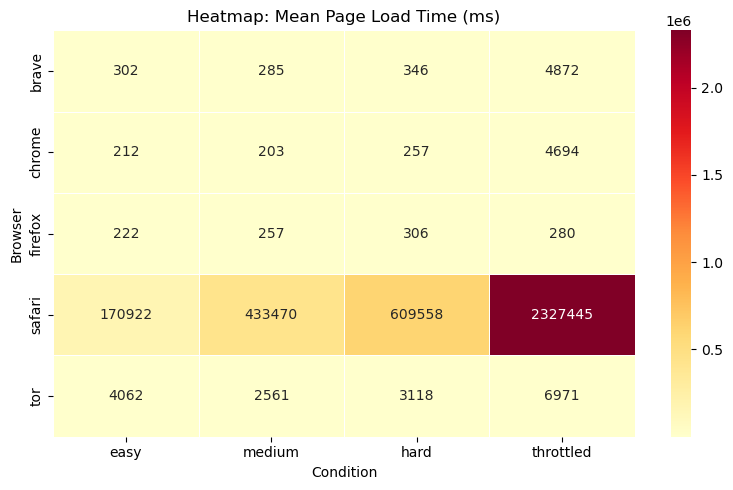

In [22]:
plt_mean = metrics_df.groupby(['browser', 'condition'])['plt_ms'].mean().unstack()
plt_mean = plt_mean[['easy', 'medium', 'hard', 'throttled']]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(plt_mean, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Heatmap: Mean Page Load Time (ms)')
ax.set_xlabel('Condition')
ax.set_ylabel('Browser')
plt.tight_layout()
plt.show()

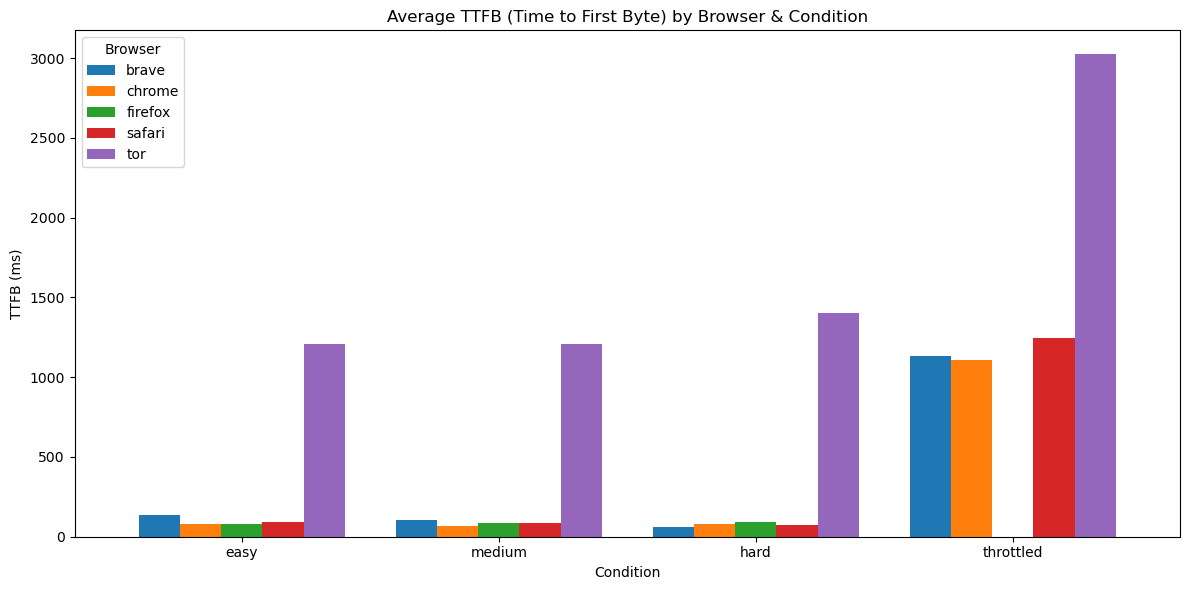

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

ttfb_data = metrics_df.groupby(['browser', 'condition'])['ttfb_ms'].mean().reset_index()
pivot = ttfb_data.pivot(index='condition', columns='browser', values='ttfb_ms')
pivot = pivot.reindex(['easy', 'medium', 'hard', 'throttled'])

pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Average TTFB (Time to First Byte) by Browser & Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('TTFB (ms)')
ax.legend(title='Browser')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

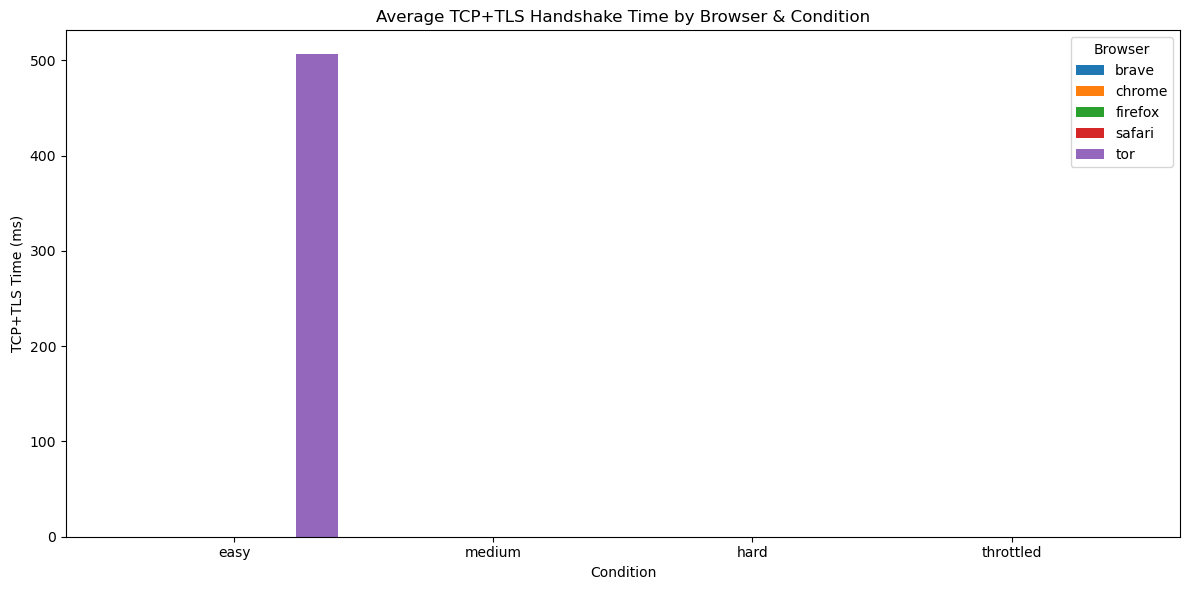

In [16]:
# TCP + TLS Handshake Time
fig, ax = plt.subplots(figsize=(12, 6))
tls_data = metrics_df.groupby(['browser', 'condition'])['tcp_tls_ms'].mean().reset_index()
pivot = tls_data.pivot(index='condition', columns='browser', values='tcp_tls_ms')
pivot = pivot.reindex(['easy', 'medium', 'hard', 'throttled'])
pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Average TCP+TLS Handshake Time by Browser & Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('TCP+TLS Time (ms)')
ax.legend(title='Browser')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

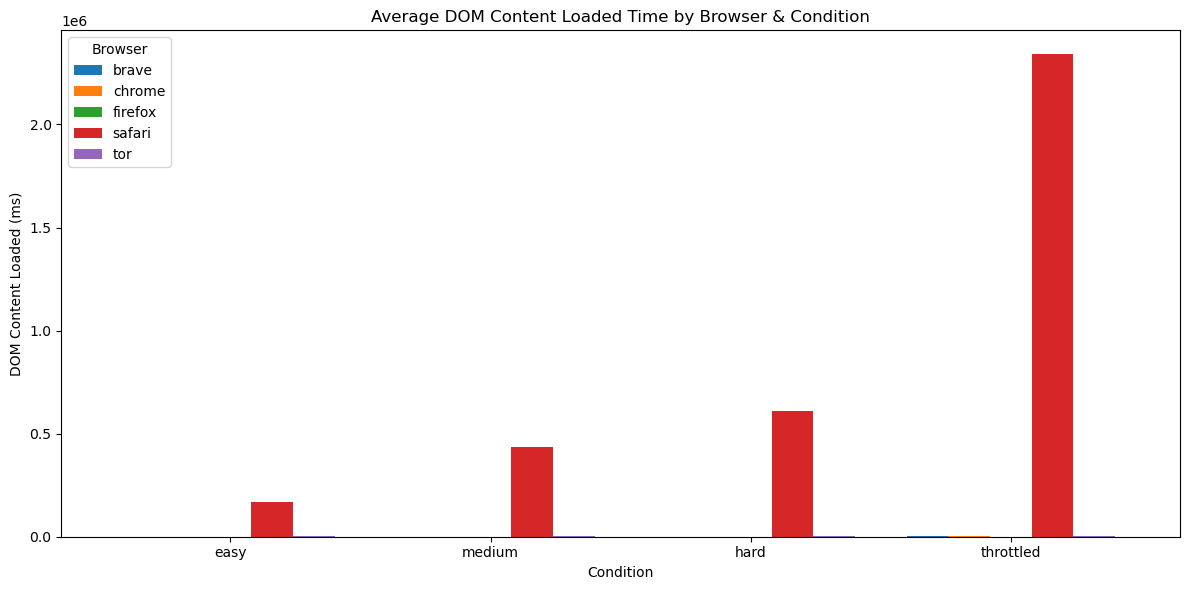

In [21]:
# DOM Content Loaded Time
fig, ax = plt.subplots(figsize=(12, 6))
dom_data = metrics_df.groupby(['browser', 'condition'])['oncontent_ms'].mean().reset_index()
pivot = dom_data.pivot(index='condition', columns='browser', values='oncontent_ms')
pivot = pivot.reindex(['easy', 'medium', 'hard', 'throttled'])
pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Average DOM Content Loaded Time by Browser & Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('DOM Content Loaded (ms)')
ax.legend(title='Browser')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

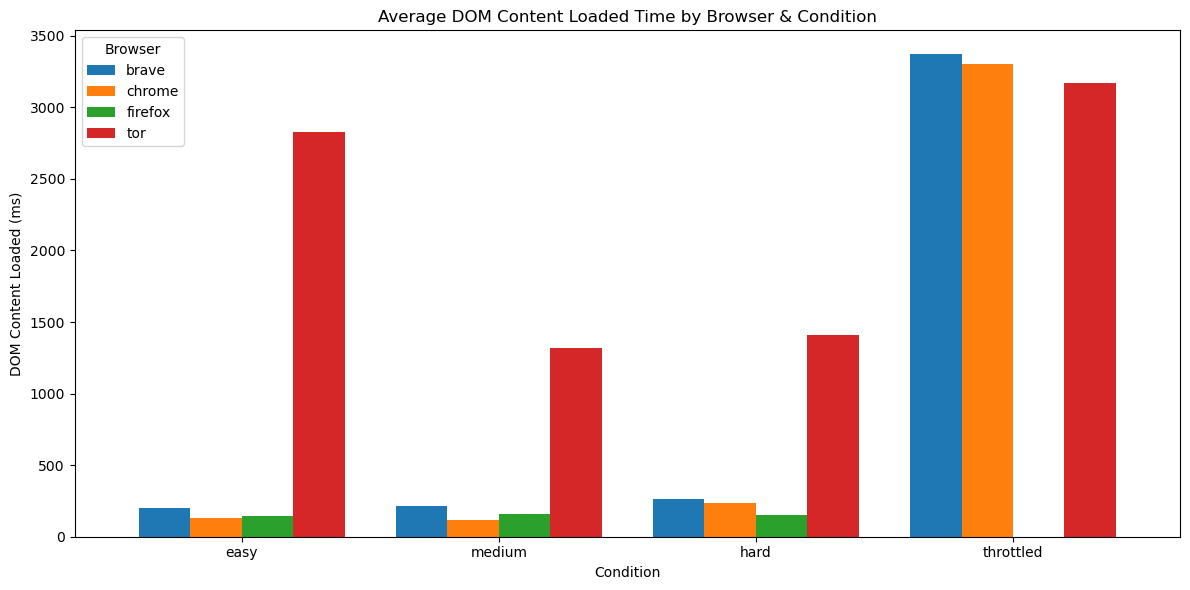

In [20]:
# DOM Content Loaded Time
fig, ax = plt.subplots(figsize=(12, 6))
filtered_df = metrics_df[metrics_df['browser'] != 'safari']
dom_data = filtered_df.groupby(['browser', 'condition'])['oncontent_ms'].mean().reset_index()
pivot = dom_data.pivot(index='condition', columns='browser', values='oncontent_ms')
pivot = pivot.reindex(['easy', 'medium', 'hard', 'throttled'])
pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Average DOM Content Loaded Time by Browser & Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('DOM Content Loaded (ms)')
ax.legend(title='Browser')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

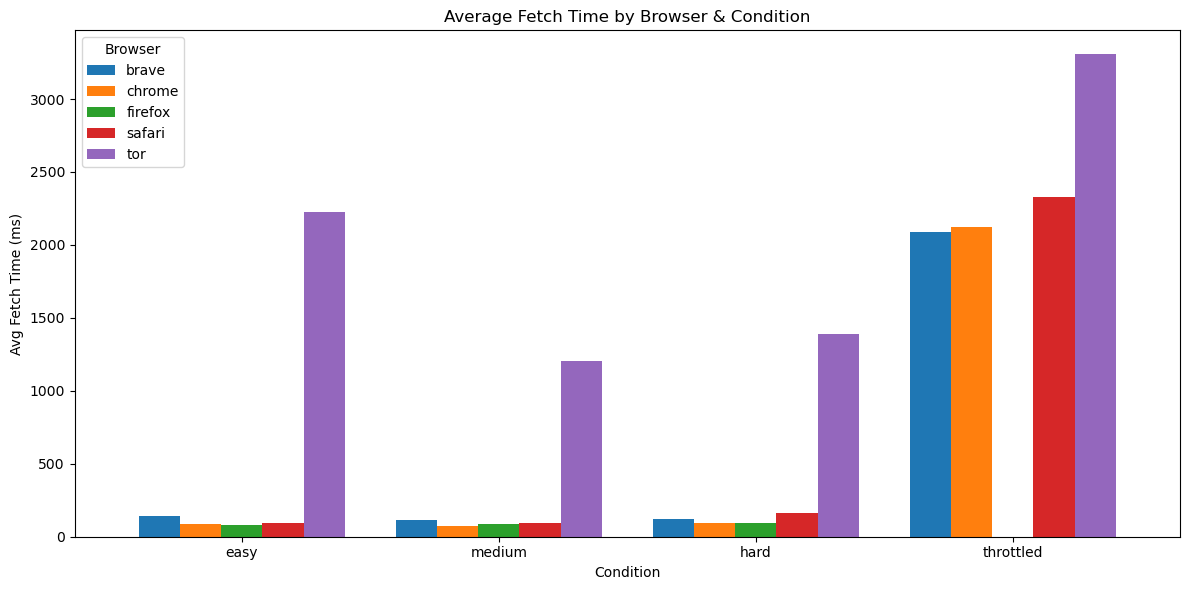

In [22]:
# Average Fetch Time
fig, ax = plt.subplots(figsize=(12, 6))
fetch_data = metrics_df.groupby(['browser', 'condition'])['avg_fetch_ms'].mean().reset_index()
pivot = fetch_data.pivot(index='condition', columns='browser', values='avg_fetch_ms')
pivot = pivot.reindex(['easy', 'medium', 'hard', 'throttled'])
pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Average Fetch Time by Browser & Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('Avg Fetch Time (ms)')
ax.legend(title='Browser')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

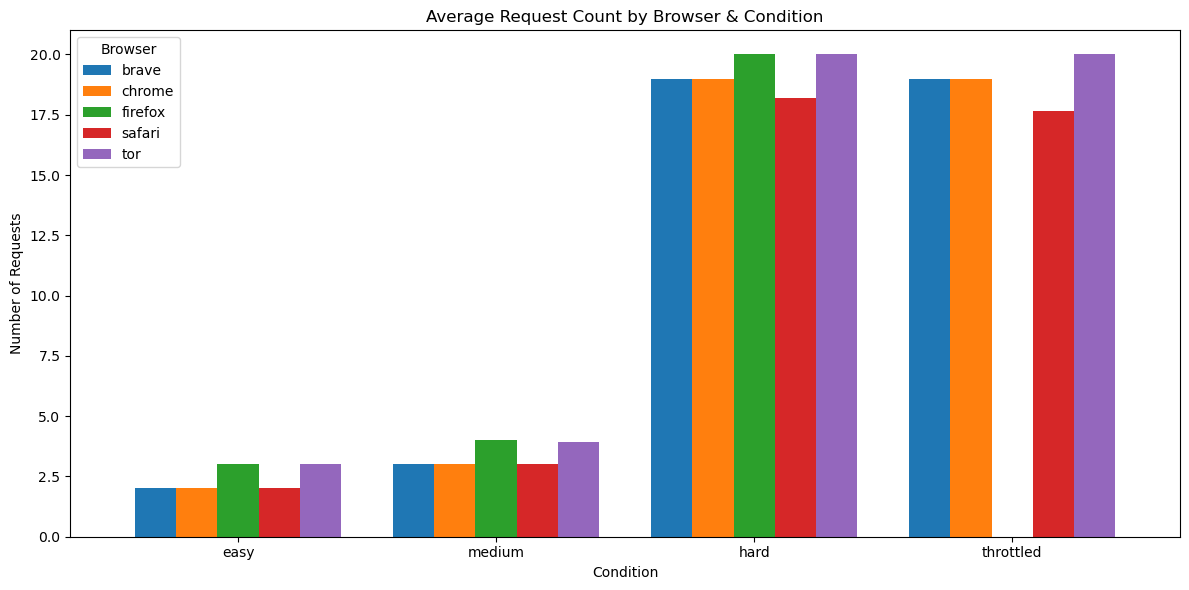

In [23]:

fig, ax = plt.subplots(figsize=(12, 6))
req_data = metrics_df.groupby(['browser', 'condition'])['requests'].mean().reset_index()
pivot = req_data.pivot(index='condition', columns='browser', values='requests')
pivot = pivot.reindex(['easy', 'medium', 'hard', 'throttled'])
pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Average Request Count by Browser & Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('Number of Requests')
ax.legend(title='Browser')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

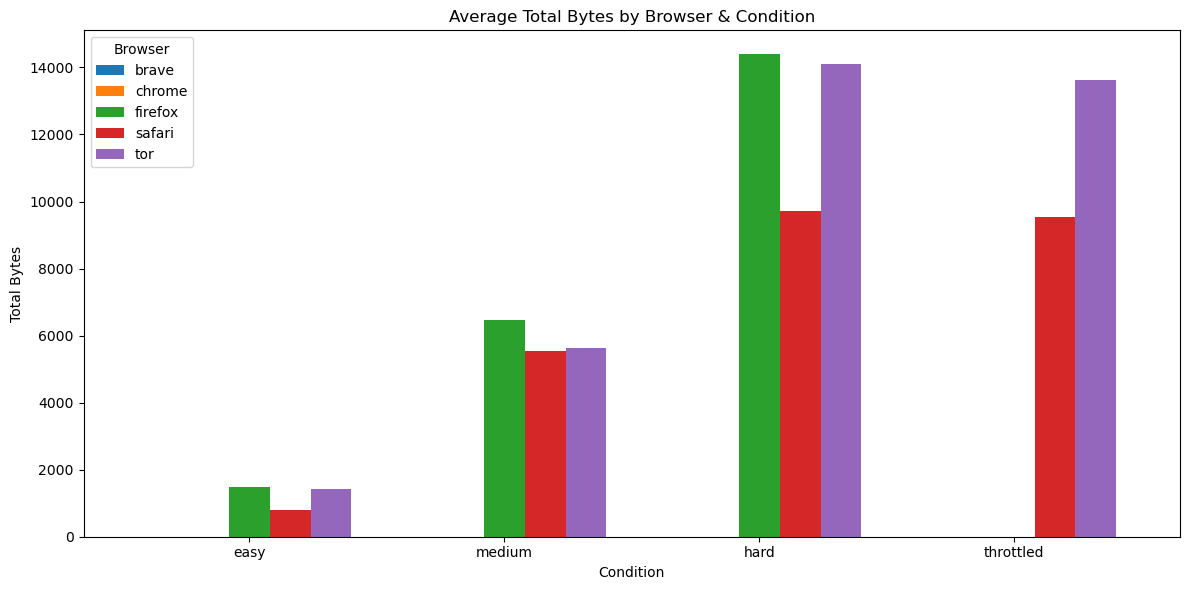

In [24]:

fig, ax = plt.subplots(figsize=(12, 6))
bytes_data = metrics_df.groupby(['browser', 'condition'])['total_bytes'].mean().reset_index()
pivot = bytes_data.pivot(index='condition', columns='browser', values='total_bytes')
pivot = pivot.reindex(['easy', 'medium', 'hard', 'throttled'])
pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Average Total Bytes by Browser & Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('Total Bytes')
ax.legend(title='Browser')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

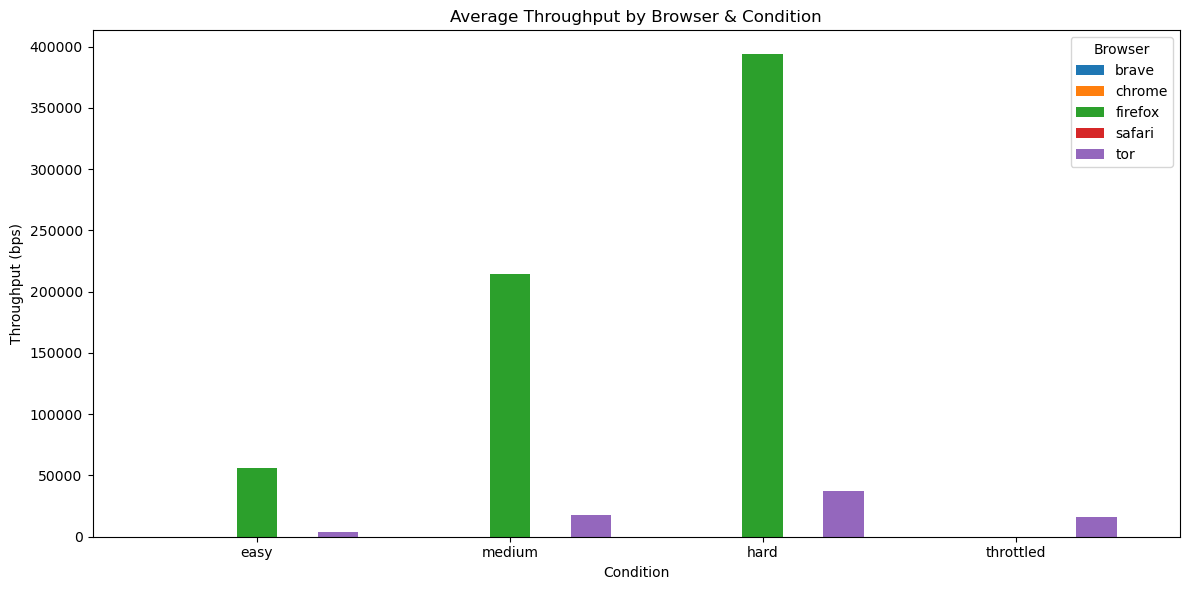

In [25]:
# Throughput
fig, ax = plt.subplots(figsize=(12, 6))
tp_data = metrics_df.groupby(['browser', 'condition'])['throughput_bps'].mean().reset_index()
pivot = tp_data.pivot(index='condition', columns='browser', values='throughput_bps')
pivot = pivot.reindex(['easy', 'medium', 'hard', 'throttled'])
pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Average Throughput by Browser & Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('Throughput (bps)')
ax.legend(title='Browser')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

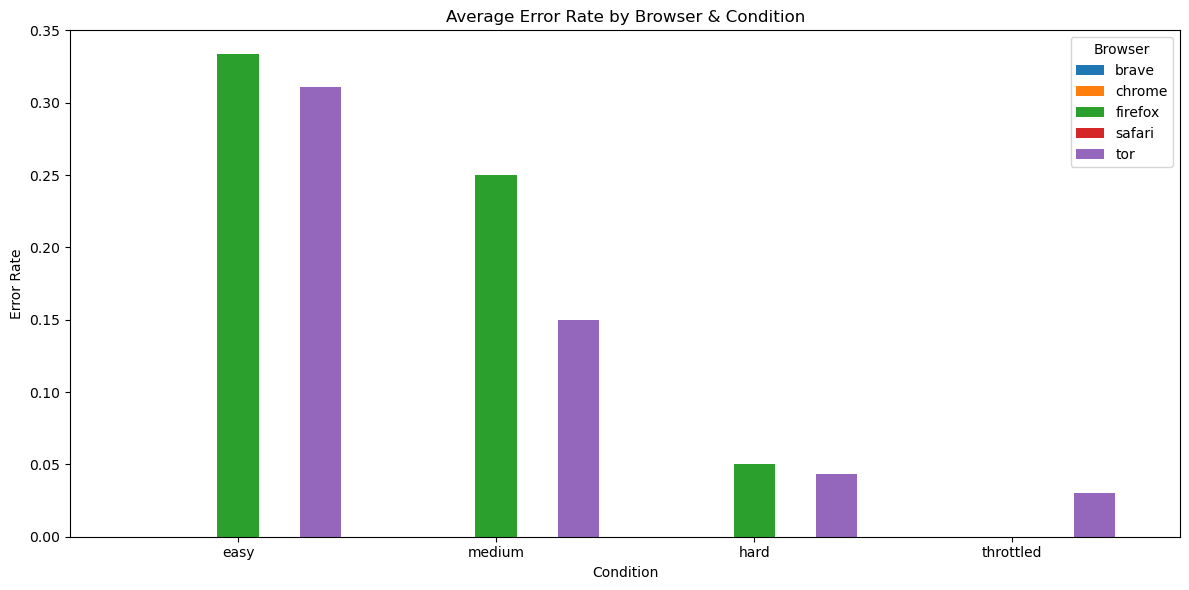

In [26]:
# Error Rate
fig, ax = plt.subplots(figsize=(12, 6))
err_data = metrics_df.groupby(['browser', 'condition'])['error_rate'].mean().reset_index()
pivot = err_data.pivot(index='condition', columns='browser', values='error_rate')
pivot = pivot.reindex(['easy', 'medium', 'hard', 'throttled'])
pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Average Error Rate by Browser & Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('Error Rate')
ax.legend(title='Browser')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

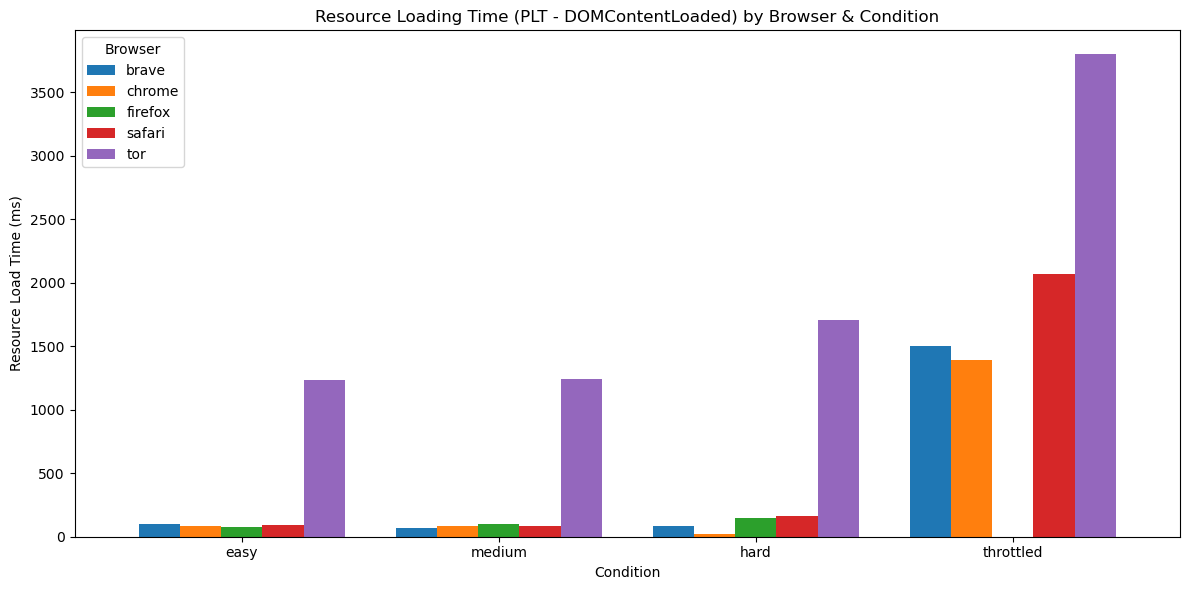

In [27]:
# Resource Loading Time (PLT - DOMContentLoaded)
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df['resource_load_ms'] = metrics_df['plt_ms'] - metrics_df['oncontent_ms']
res_data = metrics_df.groupby(['browser', 'condition'])['resource_load_ms'].mean().reset_index()
pivot = res_data.pivot(index='condition', columns='browser', values='resource_load_ms')
pivot = pivot.reindex(['easy', 'medium', 'hard', 'throttled'])
pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Resource Loading Time (PLT - DOMContentLoaded) by Browser & Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('Resource Load Time (ms)')
ax.legend(title='Browser')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

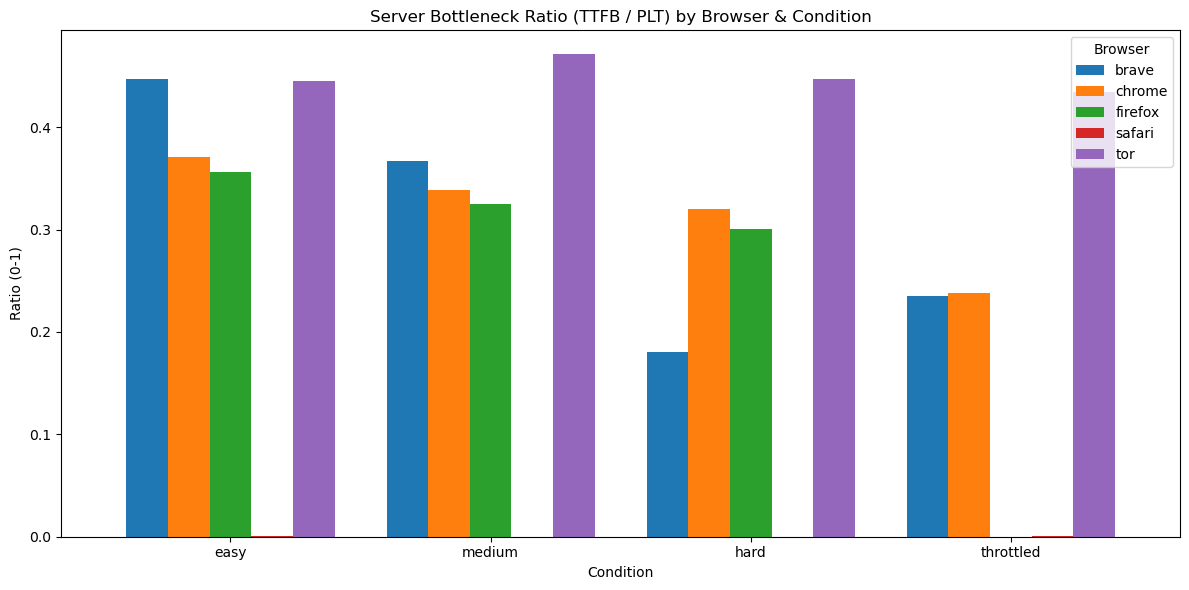

In [28]:
# Server vs Total Load Ratio (TTFB / PLT)
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df['server_ratio'] = metrics_df['ttfb_ms'] / metrics_df['plt_ms']
ratio_data = metrics_df.groupby(['browser', 'condition'])['server_ratio'].mean().reset_index()
pivot = ratio_data.pivot(index='condition', columns='browser', values='server_ratio')
pivot = pivot.reindex(['easy', 'medium', 'hard', 'throttled'])
pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Server Bottleneck Ratio (TTFB / PLT) by Browser & Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('Ratio (0-1)')
ax.legend(title='Browser')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

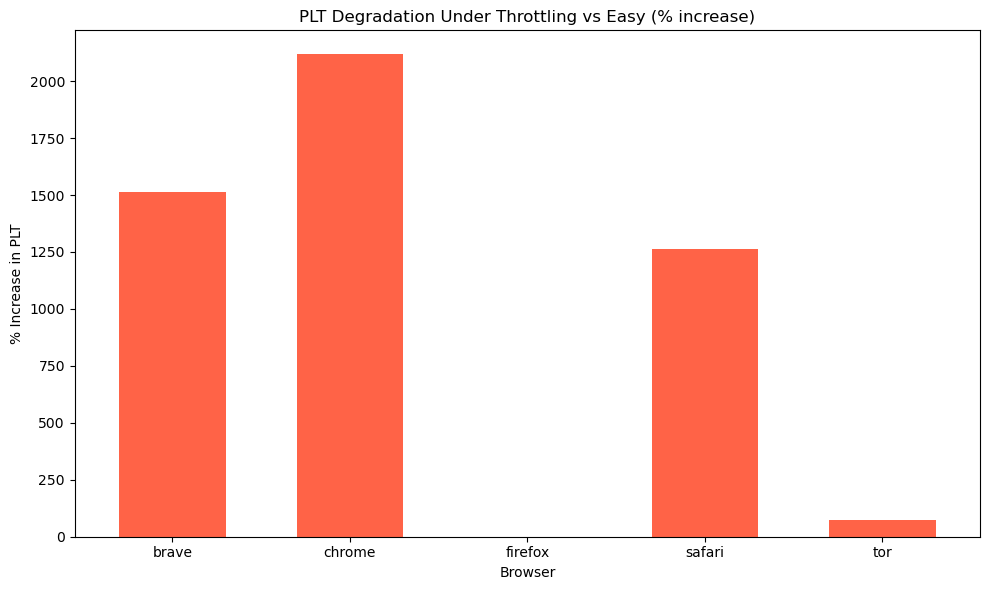

In [29]:
# Throttle Degradation (% PLT increase from easy to throttled)
fig, ax = plt.subplots(figsize=(10, 6))
easy_plt = metrics_df[metrics_df['condition'] == 'easy'].groupby('browser')['plt_ms'].mean()
throttled_plt = metrics_df[metrics_df['condition'] == 'throttled'].groupby('browser')['plt_ms'].mean()
degradation = ((throttled_plt - easy_plt) / easy_plt * 100)
degradation.plot(kind='bar', ax=ax, width=0.6, color='tomato')
ax.set_title('PLT Degradation Under Throttling vs Easy (% increase)')
ax.set_xlabel('Browser')
ax.set_ylabel('% Increase in PLT')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()